# Blackjack CV — Entrenamiento YOLOv8 en Google Colab

Entrena el modelo de detección de cartas. Ejecútalo en Google Colab
para aprovechar la GPU gratuita (T4 es suficiente).

## Pasos previos (en tu Raspberry Pi)

### Opción A — Fotos reales *(recomendado para mayor precisión)*

**1.** Captura ≥100 fotos por clase (14 clases = ≥1400 fotos en total):
```bash
python scripts/capture_dataset.py
```

**2.** Auto-genera las anotaciones YOLO:
```bash
python scripts/auto_annotate.py --preview   # revisa las bboxes visualmente
python scripts/auto_annotate.py             # o directo sin preview
```

**3.** Comprime y sube a Google Drive:
```bash
cd data && zip -r labeled.zip labeled/
```
Sube `labeled.zip` a cualquier carpeta de tu Drive.

---

### Opción B — Datos sintéticos *(arranque rápido, menor precisión)*

**1.** Genera el dataset sintético:
```bash
python scripts/generate_synthetic_data.py --n 3000 --out data/synthetic
```

**2.** Comprime y sube:
```bash
cd data && zip -r synthetic.zip synthetic/
```
Sube `synthetic.zip` a Google Drive.

---

Después ejecuta las celdas de este notebook en orden.

## 1. Verificar entorno y GPU

In [1]:
import os

if not os.path.exists('/content'):
    raise RuntimeError('Ejecuta este notebook en Google Colab')

import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                         '--format=csv,noheader'], capture_output=True, text=True)
if result.returncode == 0:
    print('GPU disponible:', result.stdout.strip())
else:
    print('⚠️  Sin GPU — ve a Entorno de ejecución → Cambiar tipo → T4 GPU')

GPU disponible: Tesla T4, 15360 MiB


## 2. Instalar dependencias

In [2]:
!pip install ultralytics -q
from ultralytics import YOLO
print('Ultralytics instalado correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics instalado correctamente


## 3. Montar Google Drive y extraer dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import glob

# Busca primero fotos reales (labeled.zip), luego datos sintéticos (synthetic.zip)
ZIP_PATH = None
for name in ('labeled.zip', 'synthetic.zip'):
    matches = glob.glob(f'/content/drive/MyDrive/**/{name}', recursive=True)
    if matches:
        ZIP_PATH = matches[0]
        print(f'Encontrado ({name}): {ZIP_PATH}')
        break

if ZIP_PATH is None:
    raise FileNotFoundError(
        'No se encontró labeled.zip ni synthetic.zip en Google Drive.\n'
        'Consulta las instrucciones en la primera celda.'
    )

Encontrado (labeled.zip): /content/drive/MyDrive/dataPoker/labeled.zip


In [6]:
import zipfile, pathlib

DATASET_DIR = pathlib.Path('/content/dataset')
DATASET_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATASET_DIR)

# Localizar dataset.yaml
yamls = list(DATASET_DIR.rglob('dataset.yaml'))
if not yamls:
    raise FileNotFoundError('dataset.yaml no encontrado dentro del zip')

YAML_PATH = str(yamls[0])

# Corregir la ruta 'path' dentro del yaml para que apunte a Colab
import re
content = pathlib.Path(YAML_PATH).read_text()
content = re.sub(r'^path:.*$', f'path: {yamls[0].parent}', content, flags=re.MULTILINE)
pathlib.Path(YAML_PATH).write_text(content)

print(f'Dataset extraído en: {DATASET_DIR}')
print(f'dataset.yaml: {YAML_PATH}')

# Contar imágenes
n_train = len(list((yamls[0].parent / 'images' / 'train').glob('*.jpg')))
n_val   = len(list((yamls[0].parent / 'images' / 'val').glob('*.jpg')))
print(f'Imágenes — train: {n_train}  val: {n_val}')

Dataset extraído en: /content/dataset
dataset.yaml: /content/dataset/labeled/dataset.yaml
Imágenes — train: 1164  val: 286


## 4. Entrenar el modelo

In [7]:
# Parámetros de entrenamiento
# Con fotos reales: epochs=100, patience=20 da mejores resultados
# Con datos sintéticos: epochs=50 es suficiente
EPOCHS    = 100    # aumenta si el modelo no converge (monitoriza mAP50 en logs)
IMG_SIZE  = 640
BATCH     = 16     # reduce a 8 si hay error de memoria
MODEL     = 'yolov8n.pt'   # nano: rápido y ligero, suficiente para la Pi

model = YOLO(MODEL)

results = model.train(
    data     = YAML_PATH,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    name     = 'blackjack_v1',
    project  = '/content/runs',
    patience = 20,        # para si no mejora en 20 épocas
    # Augmentación — reduce agresividad para fotos reales con poco dato
    degrees  = 15,        # rotación máxima
    translate= 0.1,
    scale    = 0.4,
    fliplr   = 0.5,
    mosaic   = 0.5,       # baja a 0.0 si hay sobreajuste
    verbose  = True,
)

print('\nEntrenamiento completado.')
print(f'mAP50: {results.results_dict.get("metrics/mAP50(B)", "N/A")}')
print('Objetivo con fotos reales: mAP50 > 0.90')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/labeled/dataset.yaml, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=blackjack_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

## 5. Evaluar el modelo

In [8]:
best_model_path = '/content/runs/blackjack_v1/weights/best.pt'
best = YOLO(best_model_path)
metrics = best.val(data=YAML_PATH)

print(f'mAP50   : {metrics.box.map50:.3f}')
print(f'mAP50-95: {metrics.box.map:.3f}')
print(f'Precision: {metrics.box.p.mean():.3f}')
print(f'Recall  : {metrics.box.r.mean():.3f}')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3413.6±998.0 MB/s, size: 168.1 KB)
val: Scanning /content/dataset/labeled/labels/val.cache... 286 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 286/286 75.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.1it/s 5.8s
                   all        286        286      0.942      0.898       0.96      0.949
                     A         22         22      0.954      0.935      0.953      0.953
                     2         20         20      0.884      0.761      0.925      0.916
                     3         21         21          1        0.9      0.959      0.942
                     4         21         21      0.736      0.952       0.95      0.947
                     5         20         

## 6. Ver ejemplos de detección

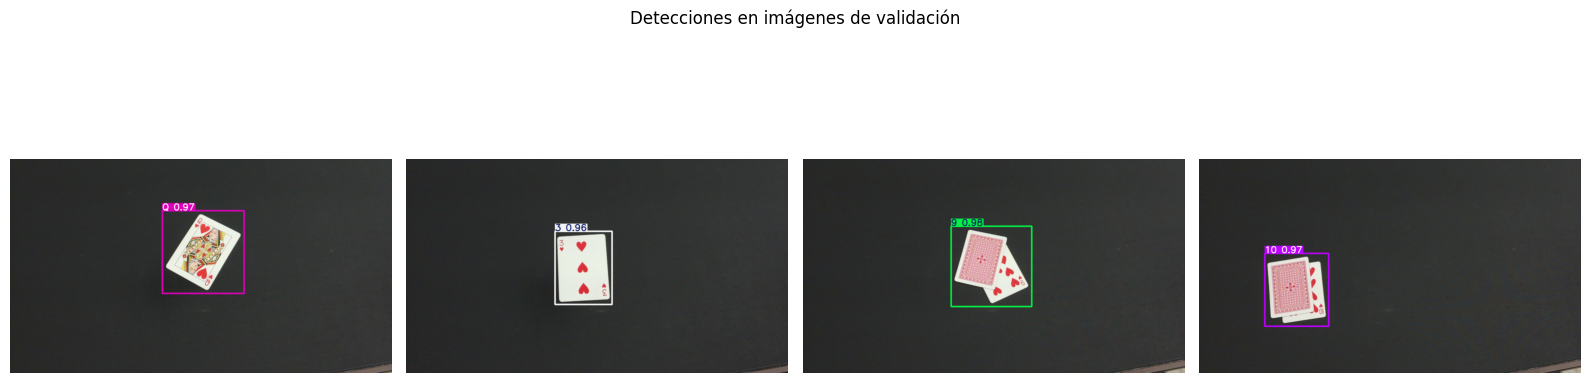

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, random

val_images = glob.glob(str(yamls[0].parent / 'images' / 'val' / '*.jpg'))
sample     = random.sample(val_images, min(4, len(val_images)))

results_pred = best(sample, verbose=False)

fig, axes = plt.subplots(1, len(sample), figsize=(16, 5))
if len(sample) == 1:
    axes = [axes]

for ax, r in zip(axes, results_pred):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.axis('off')

plt.suptitle('Detecciones en imágenes de validación')
plt.tight_layout()
plt.show()

## 7. Guardar el modelo en Google Drive

In [10]:
import shutil, pathlib

DRIVE_DEST = pathlib.Path('/content/drive/MyDrive/blackjack-cv/models')
DRIVE_DEST.mkdir(parents=True, exist_ok=True)

dest = DRIVE_DEST / 'yolov8n_blackjack.pt'
shutil.copy(best_model_path, dest)

print(f'Modelo guardado en Drive: {dest}')

Modelo guardado en Drive: /content/drive/MyDrive/blackjack-cv/models/yolov8n_blackjack.pt


## 8. Copiar el modelo a la Raspberry Pi

Descarga el archivo `yolov8n_blackjack.pt` desde Google Drive y cópialo a tu Pi:

**Opción A — desde el navegador:**
1. Abre Google Drive → carpeta `blackjack-cv/models/`
2. Descarga `yolov8n_blackjack.pt`
3. Cópialo a la Pi con un USB o con `scp`

**Opción B — directamente en la Pi con gdown:**
```bash
pip install gdown
gdown 'URL_DEL_ARCHIVO' -O ~/projects/blackjack-cv/models/yolov8n_blackjack.pt
```
(La URL la obtienes haciendo clic derecho → Compartir → Copiar enlace en Drive)

Una vez el modelo esté en `models/yolov8n_blackjack.pt`, arranca el sistema:
```bash
cd ~/projects/blackjack-cv
python main.py
```